# **Trabajo Práctico 2**
***

**Año:** 2025
**Materia:** Minería de Datos
**Integrantes:** Juan Andrés Morales, Genaron Canciani
***

# Árboles

## EDA Companies

In [212]:
# Análisis exploratorio
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Preparación de los datos
from feature_engine.outliers import Winsorizer # remoción de outliers
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
# modelos
from sklearn.tree import DecisionTreeRegressor,DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_absolute_error, mean_squared_error,r2_score,
                            confusion_matrix,classification_report)
from sklearn.tree import plot_tree
from sklearn.naive_bayes import MultinomialNB

In [213]:
df = pd.read_csv('1000_Companies.csv') # carga de dataset

In [214]:
df.head() # primera observacion del dataset

,RyD_Spend,Administration,MarketingSpend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [215]:
df.info() # Tipo de datos

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RyD_Spend       1000 non-null   float64
 1   Administration  1000 non-null   float64
 2   MarketingSpend  1000 non-null   float64
 3   State           1000 non-null   object 
 4   Profit          1000 non-null   float64
dtypes: float64(4), object(1)
memory usage: 39.2+ KB


In [216]:
df.describe() 

,RyD_Spend,Administration,MarketingSpend,Profit
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,81668.927200,122963.897612,226205.058419,119546.164656
std,46537.567891,12613.927535,91578.393542,42888.633848
min,0.000000,51283.140000,0.000000,14681.400000
25%,43084.500000,116640.684850,150969.584600,85943.198543
50%,79936.000000,122421.612150,224517.887350,117641.466300
75%,124565.500000,129139.118000,308189.808525,155577.107425
max,165349.200000,321652.140000,471784.100000,476485.430000


In [217]:
print(df.isna().sum()[df.isna().sum() > 0]) # No hay nulos.

Series([], dtype: int64)


In [218]:
df.State.unique() # valores únicos de la variable estado

array(['New York', 'California', 'Florida'], dtype=object)

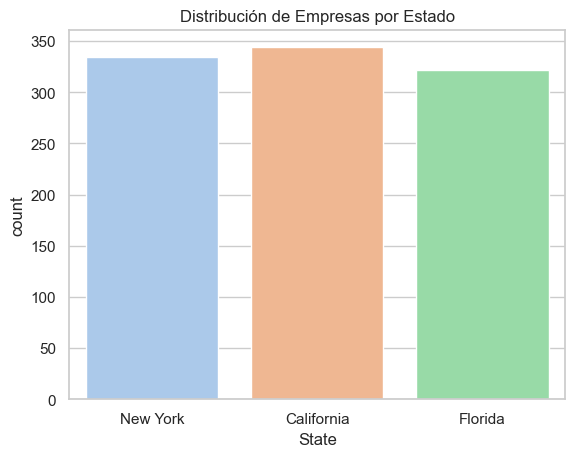

In [219]:
df['State'].value_counts()
sns.countplot(data=df, x='State', hue='State')
plt.title('Distribución de Empresas por Estado')
plt.show()


La cantidad de datos por estado es pareja.

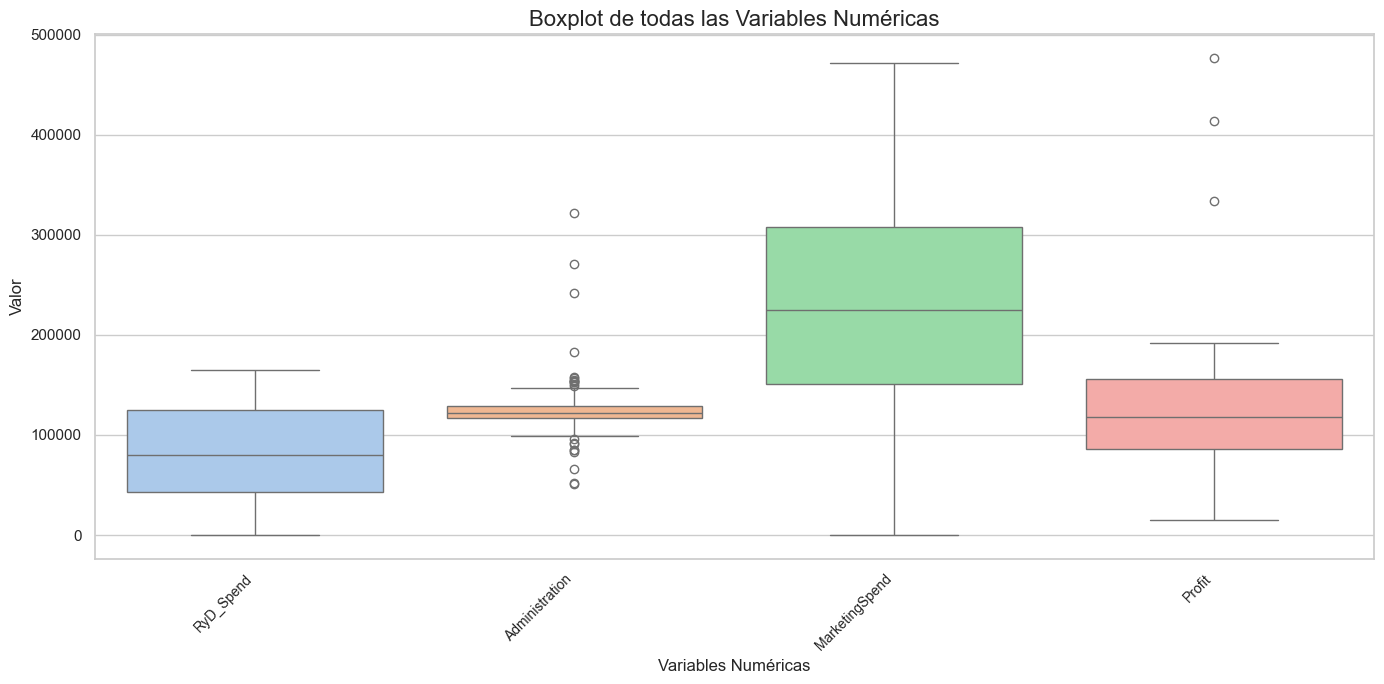

In [220]:
numerical_cols = df.select_dtypes(include=np.number).columns
df_numerical = df[numerical_cols]


plt.figure(figsize=(14, 7)) 
sns.boxplot(data=df_numerical)
plt.title('Boxplot de todas las Variables Numéricas', fontsize=16)
plt.ylabel('Valor', fontsize=12)
plt.xlabel('Variables Numéricas', fontsize=12)


plt.xticks(rotation=45, ha='right', fontsize=10) 
plt.tight_layout()
plt.show()

Se puede observar que para las variables de administration y profit se presentan valores atipicos. Se mantienen los valores para profit, ya que los mismos son atípicos pero no parecen ser imposibles.

In [221]:
df_copy = df.copy()

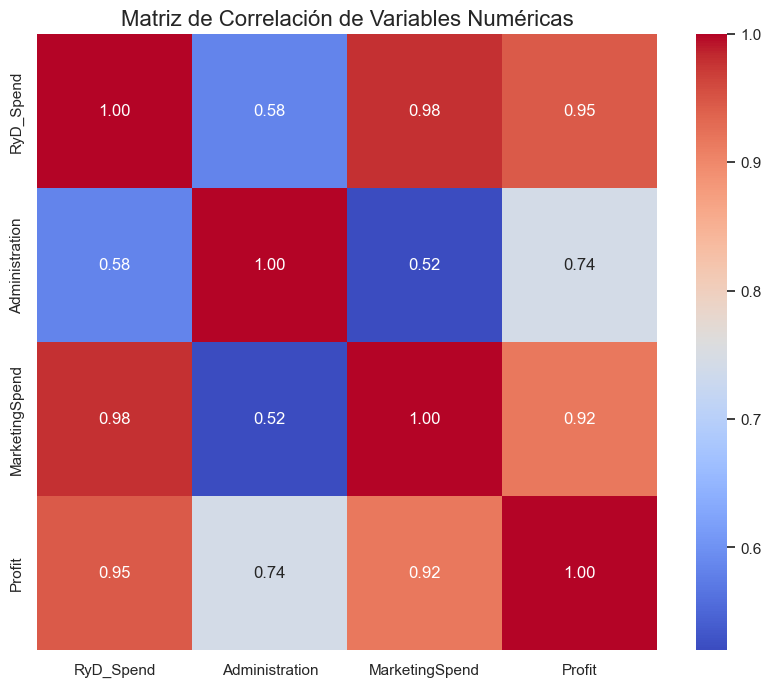

In [222]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_numerical.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

Se observan correlaciones positivas fuertes entre la variable objetivo y las variables Administration, MarketingSpend y RyD_Spend.

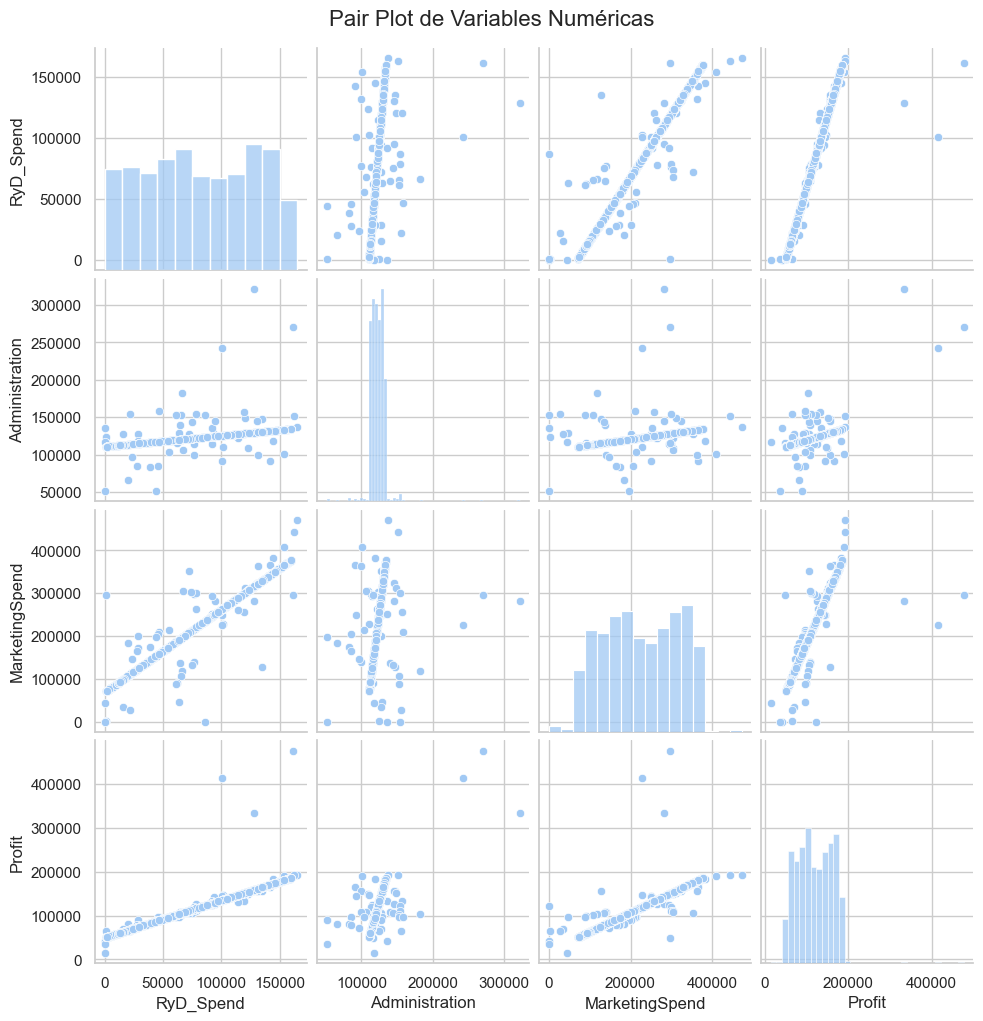

In [223]:
# Visualización de distribuciones y scatterplot de las variables numéricas
sns.pairplot(df_numerical)
plt.suptitle('Pair Plot de Variables Numéricas', y=1.02, fontsize=16) 
plt.show()

El pairplot es congruente con lo visto anteriormente en el gráfico de correlación, ya que se ve que la mayoría de las variables parecen relacionarse de una manera bastante lineal. La mayoría de las variables tienen una distribución bimodal, y tanto las variables profit como administration están sesgadas a la derecha. 

In [224]:
# OHE sobre la variable categórica State
enc = OneHotEncoder(sparse_output=False)
estados = enc.fit_transform(df_copy[['State']])
estados_df = pd.DataFrame(estados, columns=enc.get_feature_names_out(['State']), index=df_copy.index)
df_final = pd.concat([estados_df, df_copy], axis=1).drop(columns='State',axis=1)

## SPLIT Companies

In [225]:
X = df_final.drop(columns='Profit', axis=1)
y = df_final['Profit']

In [226]:
# Split de dataset 80-20
X_train80, X_test20, y_train80, y_test20  = train_test_split(X, y, test_size=0.2,
                            random_state=13, shuffle=True)

# Split de dataset 70-30
X_train70, X_test30, y_train70, y_test30  = train_test_split(X, y, test_size=0.3,
                            random_state=12, shuffle=True)

In [227]:
# Tratamiento de outliers de la variable administración en ambos split
cols = ['Administration']
winsor = Winsorizer(capping_method='iqr', tail='both',fold=1.5)

# primer split 80-20
X_train80[cols] = winsor.fit_transform(X_train80[cols])
X_test20[cols] = winsor.transform(X_test20[cols])
# segundo split 70-30
X_train70[cols] = winsor.fit_transform(X_train70[cols])
X_test20[cols] = winsor.transform(X_test30[cols])

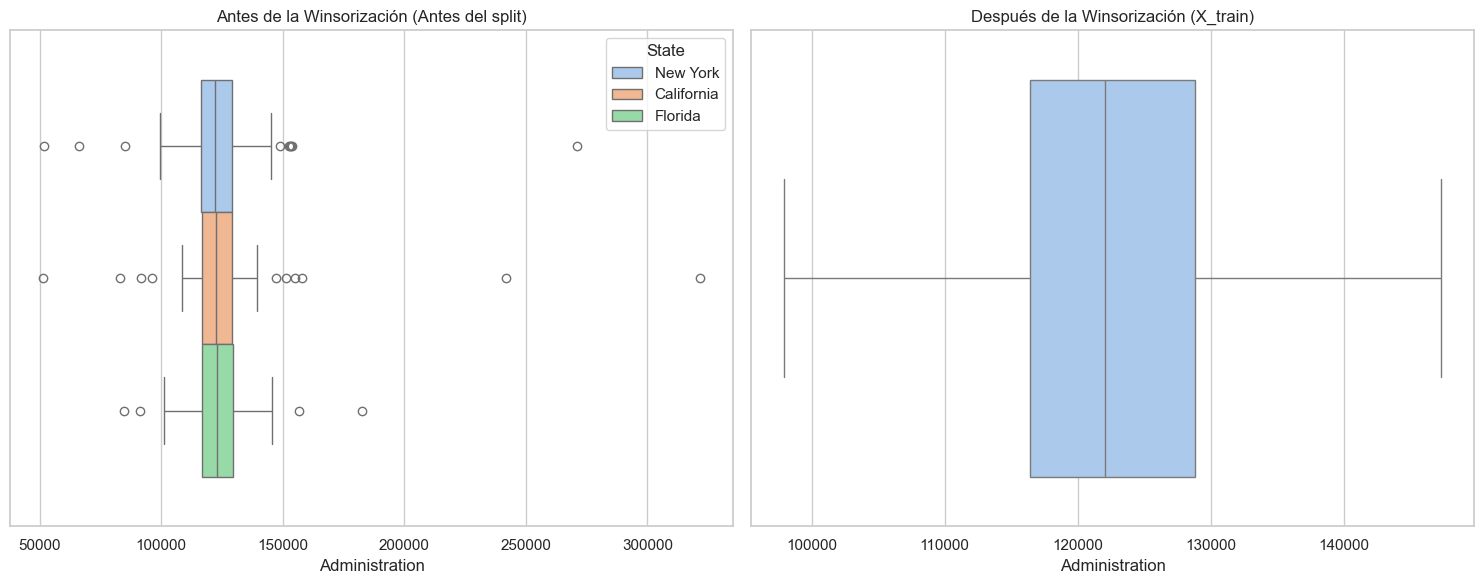

In [228]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Datos originales
sns.boxplot(data=df, x='Administration', ax=axes[0],hue = "State")
axes[0].set_title('Antes de la Winsorización (Antes del split)')

# Gráfico 2: Datos limpios
sns.boxplot(data=X_train80, x='Administration', ax=axes[1])
axes[1].set_title('Después de la Winsorización (X_train)')

plt.tight_layout()
plt.show()

Se decidió realizar un capeo de los outliers a partir de estadisticos en x_train para evitar fuga de datos, usando el método del rango intercuartílico. Como se ve en el gráfico de la izquierda(la variable antes de realizar el split), las distribuciones de el gasto en administración en los diferentes estados son muy similares en cuanto a escala, por lo que se decide recortar outliers de la variable de manera general. A la derecha se puede ver el resultado obtenido. 

In [229]:
# Escalado de datos para ambos splits
col_scl = ['RyD_Spend','Administration', 'MarketingSpend']
esc = StandardScaler()

# primer split
X_train80[col_scl] = esc.fit_transform(X_train80[col_scl])
X_test20[col_scl] = esc.transform(X_test20[col_scl])

# segundo split
X_train70[col_scl] = esc.fit_transform(X_train70[col_scl])
X_test30[col_scl] = esc.transform(X_test30[col_scl])

## Decision tree - Companies

Para determinar la configuración óptima del Árbol de Decisión de Regresión, se empleará la técnica de Búsqueda en Grilla con Validación Cruzada (GridSearchCV). Se intenta probar una cantidad amplia de valores de profundidad máxima, incluyendo a la profundidad sin límite, para que Grid Search nos permita realizar una poda del árbol en base a los resultados obtenidos del error cuadrático, que se elige como criterio de separación. También se prueban una serie de valores para la cantidad mínima de datos antes de dividir y la cantidad mínima de datos que debe haber dentro de una hoja.

In [230]:
dtr = DecisionTreeRegressor(random_state=42)

param_grid = {
    'criterion': ['squared_error'], 
    'max_depth': [3, 5, 7, 10, 12, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

### 80-20 split

In [231]:
grid_search = GridSearchCV(estimator=dtr, param_grid=param_grid, cv=5, 
                           scoring='neg_mean_squared_error', verbose=1, n_jobs=-1) # scoring con rmse para mas interpretabilidad 

# Entrenar en los datos de entrenamiento
grid_search.fit(X_train80, y_train80)

# Obtener el Mejor Modelo y Predecir
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred = best_tree.predict(X_test20)
y_pred_train80 = best_tree.predict(X_train80)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros encontrados: {'criterion': 'squared_error', 'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [232]:
mae_train = mean_absolute_error(y_train80, y_pred_train80)
mse_train = mean_squared_error(y_train80, y_pred_train80)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train80, y_pred_train80)

print(f"\nResultados en el conjunto de Train80:")
print(f"Error Absoluto Medio (MAE): {mae_train:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_train:.2f}")
print(f"R2: {r2_train}")



Resultados en el conjunto de Train80:
Error Absoluto Medio (MAE): 1753.34
Raíz del Error Cuadrático Medio (RMSE): 12701.17
R2: 0.9142469342478746


Las métricas del conjunto de train son prácticamente perfectas, lo cual puede mostrar algún indicio de overfitting. 

In [233]:
mae = mean_absolute_error(y_test20, y_pred)
mse = mean_squared_error(y_test20, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test20, y_pred)

print(f"\nResultados en el conjunto de test:")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse:.2f}")
print(f"R2: {r2}")


Resultados en el conjunto de test:
Error Absoluto Medio (MAE): 2777.45
Raíz del Error Cuadrático Medio (RMSE): 5423.89
R2: 0.9817860817360555


Las métricas obtenidas en test son incluso mejores que las obtenidas en train(casi perfectas), por lo que se intuye que el modelo ha conseguido una gran capacidad de predicción de la variable profit en base a las variables explicativas del dataset.

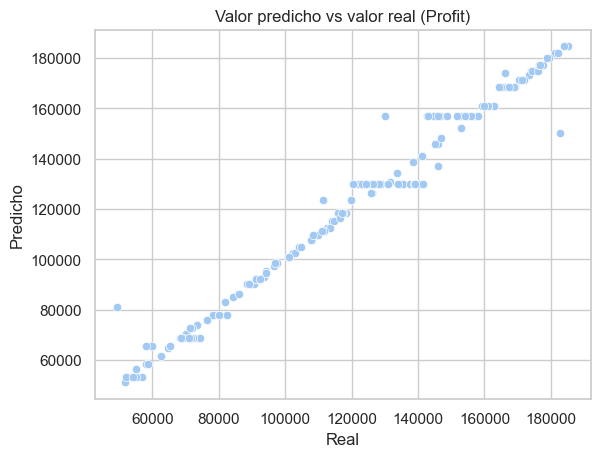

In [234]:
sns.scatterplot(x = y_test20,y = y_pred)
plt.title("Valor predicho vs valor real (Profit)")
plt.xlabel("Real")
plt.ylabel("Predicho");

El gráfico de valor real vs predicho demuestra la precisión del modelo a la hora de realizar la predicción, habiendo solo unos pocos valores cuyas predicciones son erróneas de manera considerable.

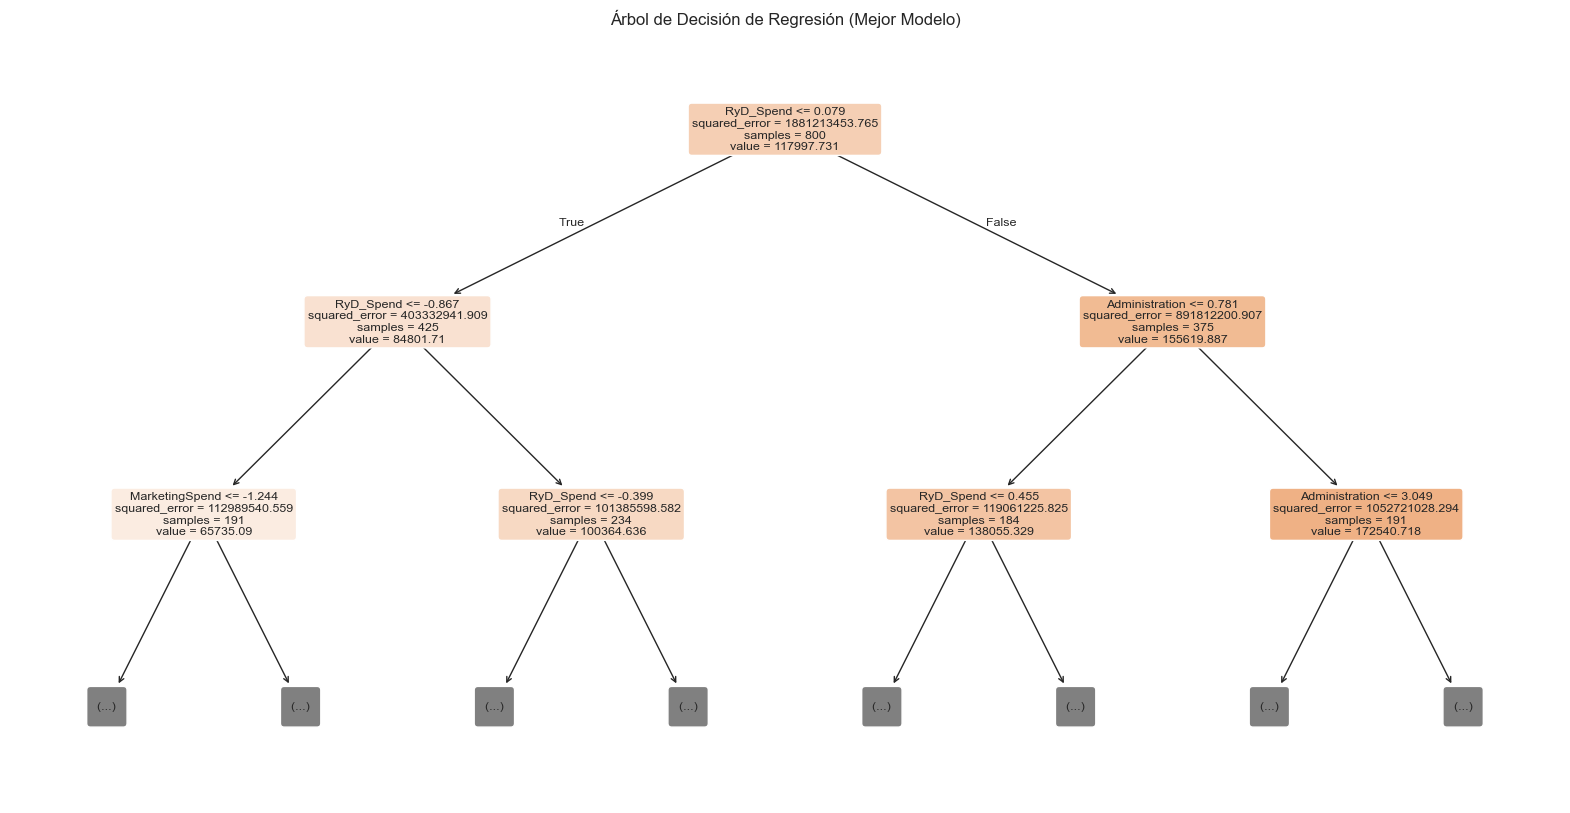

In [235]:
# Graficar el Árbol
plt.figure(figsize=(20, 10))
plot_tree(best_tree, 
          feature_names=X_train80.columns.tolist(),
          filled=True, 
          rounded=True,
          max_depth=2) # Limitar la profundidad para que sea legible
plt.title("Árbol de Decisión de Regresión (Mejor Modelo)")
plt.show()

### 70-30 split

In [ ]:
grid_search2 = GridSearchCV(estimator=dtr, param_grid=param_grid, cv=5, 
                           scoring='neg_mean_squared_error', verbose=1, n_jobs=-1) # scoring con rmse para mas interpretabilidad 

# Entrenar en los datos de entrenamiento
grid_search2.fit(X_train70, y_train70)

# Obtener el mejor modelo y predecir
print(f"Mejores parámetros encontrados: {grid_search2.best_params_}")
best_tree2 = grid_search2.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred2 = best_tree.predict(X_test30)
y_pred_train70 = best_tree.predict(X_train70)

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores parámetros encontrados: {'criterion': 'squared_error', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [237]:
mae_train2 = mean_absolute_error(y_train70, y_pred_train70)
mse_train2 = mean_squared_error(y_train70, y_pred_train70)
rmse_train2 = np.sqrt(mse_train2)
r2_train2 = r2_score(y_train70, y_pred_train70)

print(f"\nResultados en el conjunto de Train80:")
print(f"Error Absoluto Medio (MAE): {mae_train2:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_train2:.2f}")
print(f"R2: {r2_train2}")



Resultados en el conjunto de Train80:
Error Absoluto Medio (MAE): 4224.71
Raíz del Error Cuadrático Medio (RMSE): 12009.00
R2: 0.9201023272057903


In [238]:
mae_train2 = mean_absolute_error(y_test30, y_pred2)
mse_train2 = mean_squared_error(y_test30, y_pred2)
rmse_train2 = np.sqrt(mse_train2)
r2_train2 = r2_score(y_test30, y_pred2)

print(f"\nResultados en el conjunto de Train80:")
print(f"Error Absoluto Medio (MAE): {mae_train2:.2f}")
print(f"Raíz del Error Cuadrático Medio (RMSE): {rmse_train2:.2f}")
print(f"R2: {r2_train2}")



Resultados en el conjunto de Train80:
Error Absoluto Medio (MAE): 4838.13
Raíz del Error Cuadrático Medio (RMSE): 14089.03
R2: 0.8959836378578663


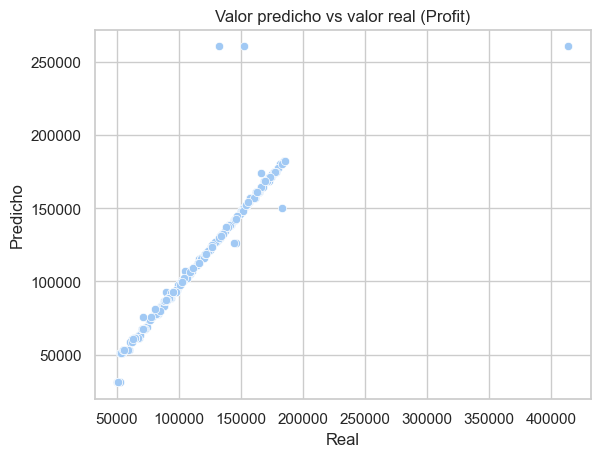

In [239]:
sns.scatterplot(x = y_test30,y = y_pred2)
plt.title("Valor predicho vs valor real (Profit)")
plt.xlabel("Real")
plt.ylabel("Predicho");

Por la naturaleza aleatoria del split, se observa que los valores outliers de Profit caen dentro del conjunto de test y se refleja en el gráfico anterior. Esto tambián indica que el modelo no tuvo exposición a valores atípicos de la variable de profit en el entrenamiento, lo que puede reducir su capacidad de generalización. Dicho esto, las métricas tanto en test como en train siguen siendo positivas, alcanzando en ambos casos un R2 mayor a 0.85.

## EDA Drugs

In [240]:
df2 = pd.read_csv('drugType.csv')

In [241]:
print(df2.isna().sum()[df2.isna().sum() > 0]) # no hay nulos

Series([], dtype: int64)


In [242]:
df2_copy = df2.copy()

In [243]:
# Conversión a categoría la columna objetivo
df2_copy['Droga'] = df2_copy['Droga'].astype('category')

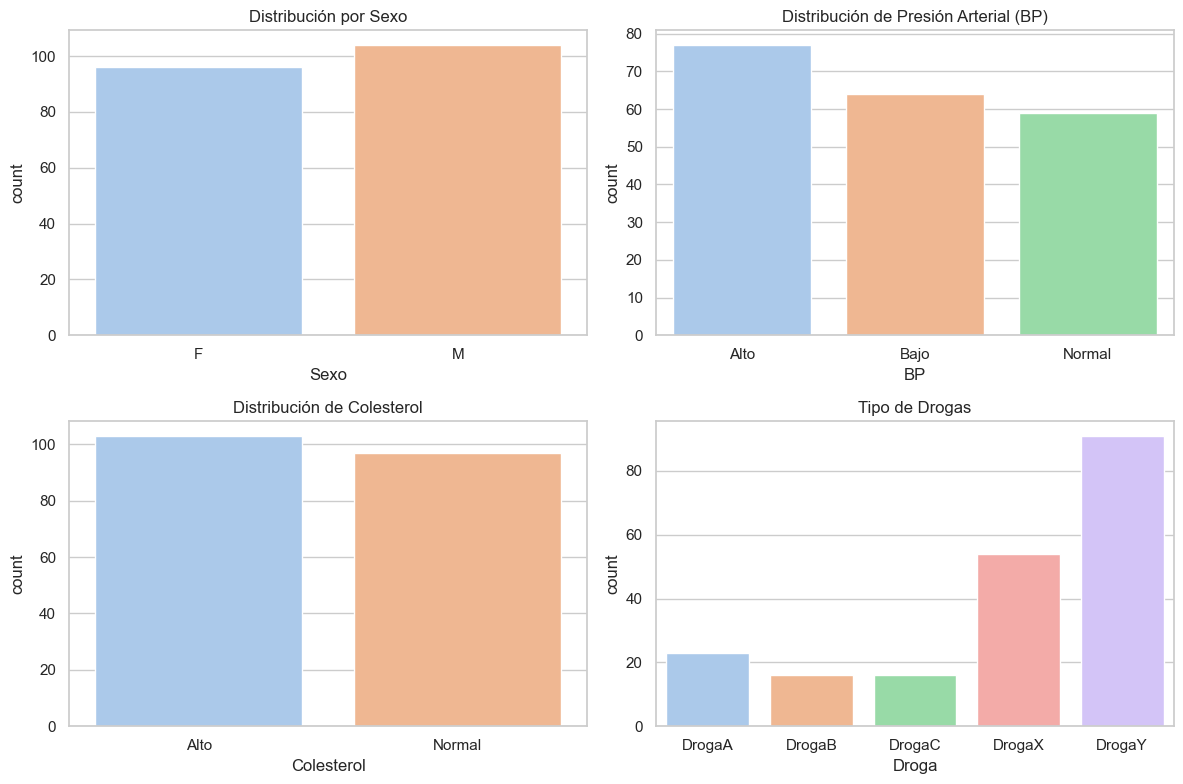

In [244]:
sns.set(style="whitegrid", palette="pastel")

# Crear figura y ejes
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Gráficos
sns.countplot(data=df2_copy, x='Sexo', hue='Sexo', ax=axes[0,0])
axes[0,0].set_title('Distribución por Sexo')

sns.countplot(data=df2_copy, x='BP', hue='BP', ax=axes[0,1])
axes[0,1].set_title('Distribución de Presión Arterial (BP)')

sns.countplot(data=df2_copy, x='Colesterol', hue='Colesterol', ax=axes[1,0])
axes[1,0].set_title('Distribución de Colesterol')

sns.countplot(data=df2_copy, x='Droga', hue='Droga', ax=axes[1,1])
axes[1,1].set_title('Tipo de Drogas')

# Ajustar espaciado
plt.tight_layout()
plt.show()


Se puede observar un desbalance de la cantidad de entradas disponibles para cada tipo de droga, habiendo menos de 20 entradas para el tipo B y el tipo C y habiendo una clara predominancia del tipo de droga Y, que cuenta con más de 80 entradas. 

Las otras variables categóricas parecen mantener una cantidad de entradas similares, a excepción de la variable de presión arterial.

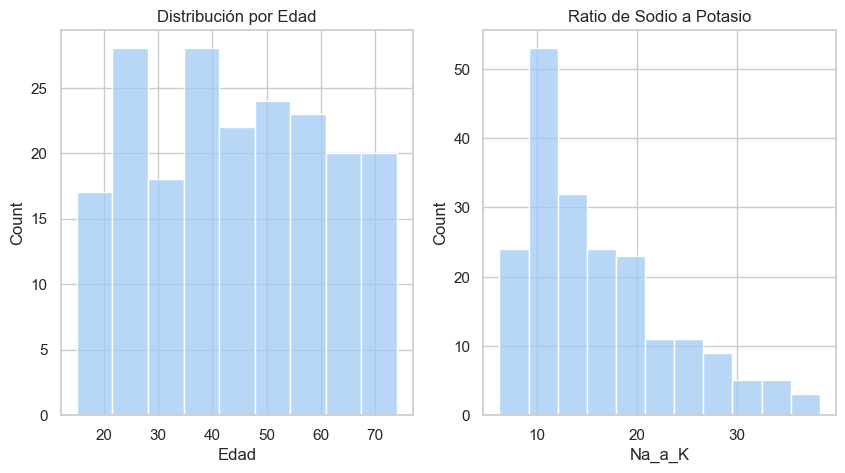

In [ ]:
sns.set(style="whitegrid", palette="pastel")

# Crear figura y ejes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Gráficos
sns.histplot(data=df2_copy, x='Edad', ax=axes[0])
axes[0].set_title('Distribución por Edad')

sns.histplot(data=df2_copy, x='Na_a_K', ax=axes[1])
axes[1].set_title('Ratio de Sodio a Potasio')

plt.show()


Se ve ligeramente sesgado a la derecha El ratio de sodio y potasio.

In [246]:
bp_map = {'Bajo': 0, 'Normal': 1, 'Alto': 2}
df2_copy['BP'] = df2_copy['BP'].map(bp_map)

In [247]:
col_map = {'Normal': 0, 'Alto': 1}
df2_copy['Colesterol'] = df2_copy['Colesterol'].map(col_map)

Se realizaron las codificaciones previas de manera ordinal debido a la naturaleza de las variables categóricas del conjunto de datos.

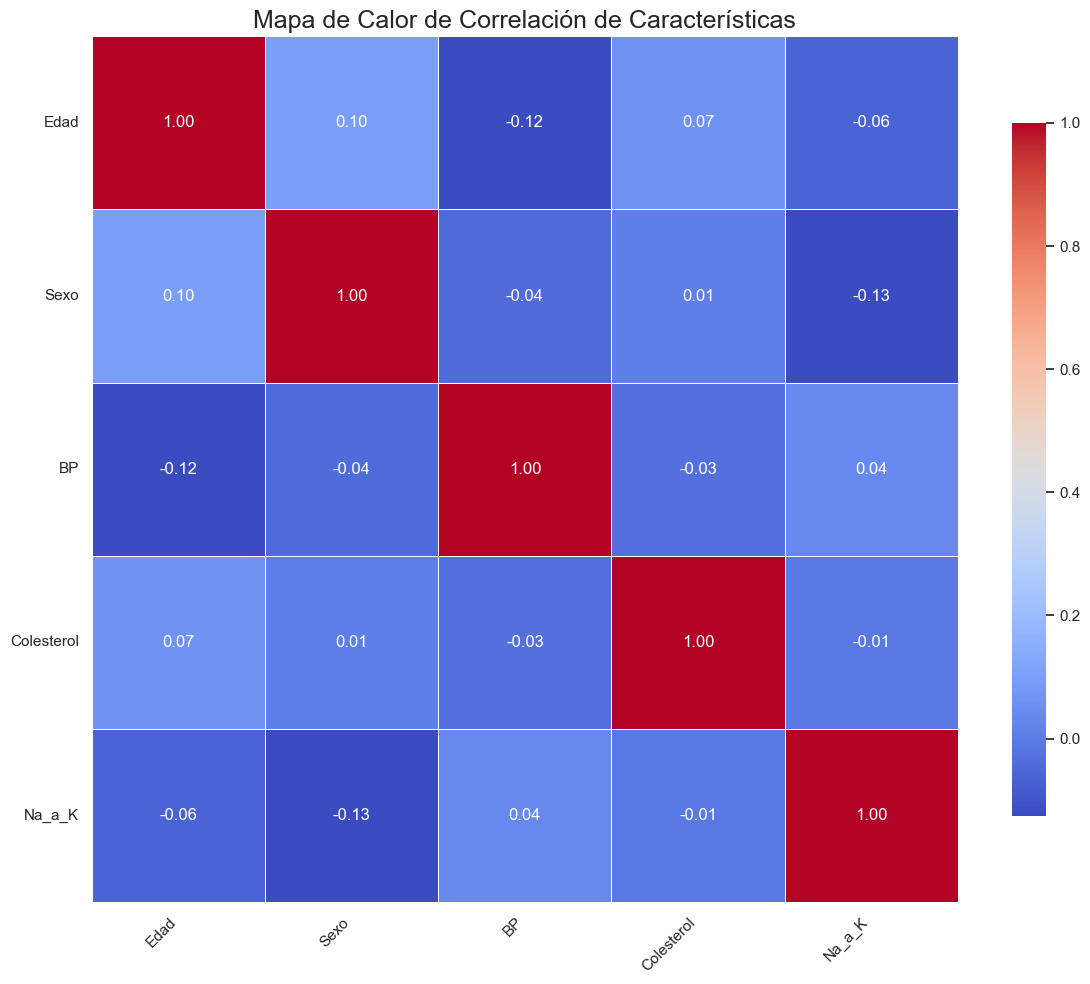

In [248]:
df_corr = df2_copy.copy()
df_corr['Sexo'] = df_corr['Sexo'].apply(lambda x: 1 if x == 'M' else 0)
corr_matrix = df_corr[['Edad', 'Sexo', 'BP', 'Colesterol', 'Na_a_K']].corr()


plt.figure(figsize=(12, 10))  


sns.heatmap(
    corr_matrix,       
    annot=True,           
    fmt=".2f",            
    cmap='coolwarm',      
    linewidths=.5,        
    cbar_kws={"shrink": .8} 
)

plt.title('Mapa de Calor de Correlación de Características', fontsize=18)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)


plt.tight_layout()
plt.show()

Las correlaciones lineales entre variables parecen no ser fuertes.

In [249]:
# OHE para la columna sexo
enc = OneHotEncoder(sparse_output=False) 

fit = enc.fit_transform(df2_copy[['Sexo']])

df_enc = pd.DataFrame(fit, columns=enc.get_feature_names_out(['Sexo']), index=df2.index)

# concatenamos los dataframe y dropeamos la columna que codificamos
df2_copy = pd.concat([df2_copy, df_enc], axis=1)
df2_copy.drop('Sexo', axis=1, inplace=True)

### SPLIT Drug

In [250]:
X = df2_copy.drop('Droga', axis=1)
y = df2_copy['Droga']

# División 80/20
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# División 70/30
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

In [251]:
columnas = ['Edad','Na_a_K','Colesterol','BP']
esc = StandardScaler()

# escalamos los split de 70-30 y 80-20
X_train_80[columnas] = esc.fit_transform(X_train_80[columnas])
X_test_20[columnas] = esc.transform(X_test_20[columnas])

X_train_70[columnas] = esc.fit_transform(X_train_70[columnas])
X_test_30[columnas] = esc.transform(X_test_30[columnas])

### Modelo 70-30

Nuevamente se utiliza Grid Search para buscar los hiperparámetros mas óptimos. Se prueba tanto el criterio de Gini como la entropía para evaluar la clasificación. Se utilizan rangos amplios de todos los otros parámetros posibles para obtener un resultado mas exhaustivo y robusto. 

In [252]:
dtr_70 = DecisionTreeClassifier(random_state=42)

param_grid_70 = {
    'criterion': ['gini', 'entropy'], # Opción principal para regresión
    'max_depth': [3, 5, 7, 10,12, None],
    'min_samples_split': [3, 5, 7, 9, 11, 13],
    'min_samples_leaf': [1, 2, 4,8,12]
}

In [253]:
grid_search = GridSearchCV(estimator=dtr_70, param_grid=param_grid_70, cv=5, 
                           scoring='f1_weighted', verbose=1, n_jobs=-1) 

# Entrenar en los datos de entrenamiento
grid_search.fit(X_train_70, y_train_70)

# --- Paso 3: Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")
best_tree = grid_search.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred_30_test = best_tree.predict(X_test_30)
y_pred_70_train = best_tree.predict(X_train_70)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3}


In [254]:
# Generar matrices de confusión.
confusion_70_train = confusion_matrix(y_train_70,y_pred_70_train)
confusion_30_test = confusion_matrix(y_test_30,y_pred_30_test)

In [255]:
# Métricas para Train
print(classification_report(y_train_70,y_pred_70_train))

              precision    recall  f1-score   support

      DrogaA       1.00      1.00      1.00        16
      DrogaB       1.00      1.00      1.00        11
      DrogaC       1.00      1.00      1.00        11
      DrogaX       1.00      1.00      1.00        38
      DrogaY       1.00      1.00      1.00        64

    accuracy                           1.00       140
   macro avg       1.00      1.00      1.00       140
weighted avg       1.00      1.00      1.00       140



Se observan métricas perfectas para train, lo cual es un gran indicio de posible overfitting.

In [256]:
# Creación de la variable nombres drogas para visualización
nombres_drogas = y_train_70.unique()

Como se ve debajo, la matriz obtenida es la perfecta, con valores solo en la diagonal.

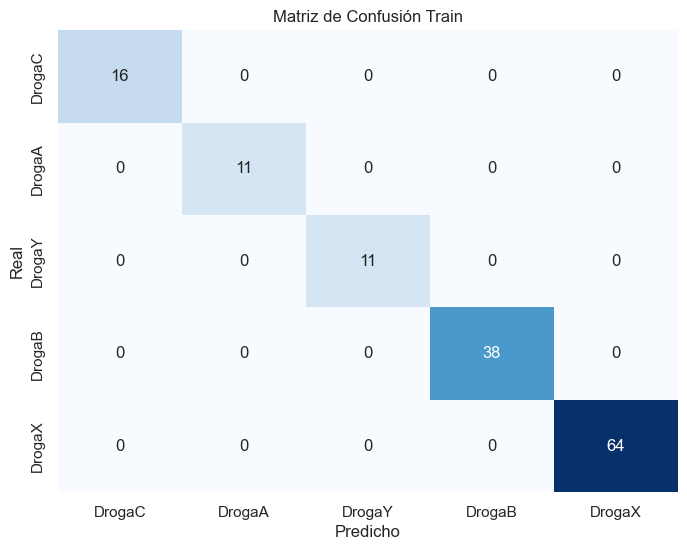

In [257]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_70_train,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Train')
plt.show()

In [258]:
# Métricas para test
print(classification_report(y_test_30,y_pred_30_test,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaC       0.88      1.00      0.93         7
      DrogaA       1.00      0.80      0.89         5
      DrogaY       1.00      1.00      1.00         5
      DrogaB       1.00      1.00      1.00        16
      DrogaX       1.00      1.00      1.00        27

    accuracy                           0.98        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.99      0.98      0.98        60



Las métricas siguen siendo extremadamente positivas en test, por lo que se intuye que el modelo logró alcanzar un buen fitting de los datos.

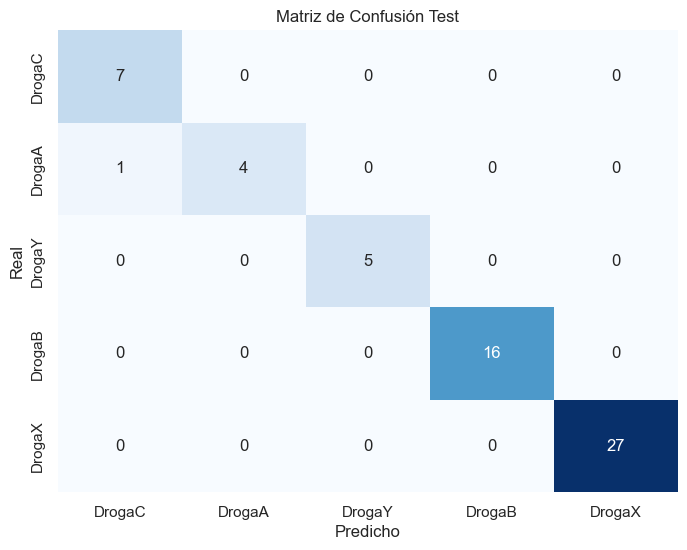

In [259]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_30_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas  
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

Solamente se predice de manera errónea un valor.

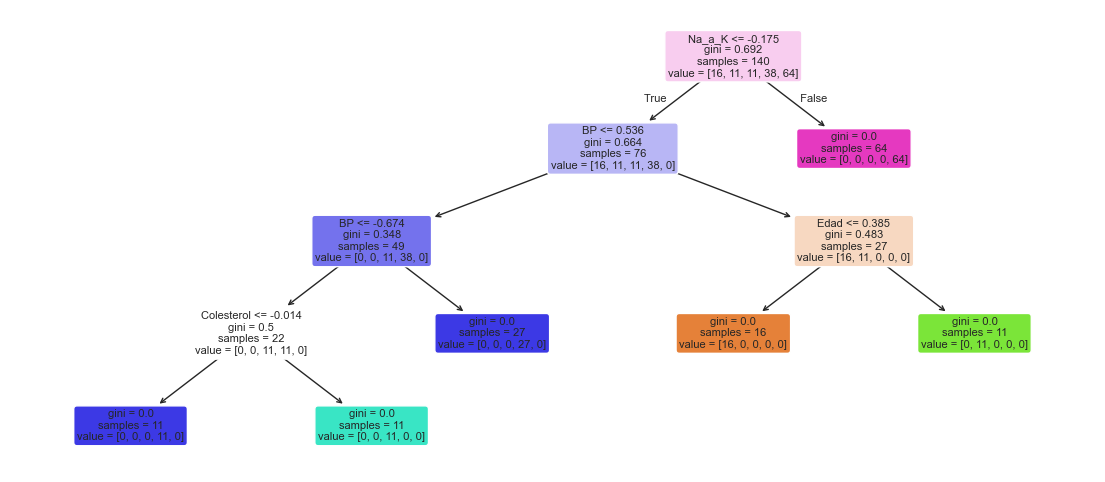

In [260]:
# Visualización del árbol obtenido
plt.figure(figsize=(14,6))
plot_tree(grid_search.best_estimator_, feature_names=X_train_70.columns, fontsize=8, filled=True,
               rounded=True)
plt.show()

### Modelo 80-20

In [261]:
dtr_80 = DecisionTreeClassifier(random_state=42)

param_grid_80 = {
    'criterion': ['gini', 'entropy'], # Opción principal para regresión
    'max_depth': [3, 5, 7,10,12, None],
    'min_samples_split': [3, 5, 7, 9, 11, 13],
    'min_samples_leaf': [1, 2, 4,8,12]
}

In [262]:
grid_search2 = GridSearchCV(estimator=dtr_80, param_grid=param_grid_80, cv=5, 
                           scoring='f1_weighted', verbose=1, n_jobs=-1) 

# Entrenar en los datos de entrenamiento
grid_search2.fit(X_train_80, y_train_80)

# --- Paso 3: Obtener el Mejor Modelo y Predecir ---
print(f"Mejores parámetros encontrados: {grid_search2.best_params_}")
best_tree = grid_search2.best_estimator_

# Realizar predicciones sobre el conjunto de test
y_pred_20_test = best_tree.predict(X_test_20)
y_pred_80_train = best_tree.predict(X_train_80)

Fitting 5 folds for each of 360 candidates, totalling 1800 fits
Mejores parámetros encontrados: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 3}


In [263]:
# Generar matrices de confusión.
confusion_80_train = confusion_matrix(y_train_80,y_pred_80_train)
confusion_20_test = confusion_matrix(y_test_20,y_pred_20_test)

Nuevamente las métricas son perfectas para train, lo cual puede indicar overfitting.

In [264]:
# Métricas para Train
print(classification_report(y_train_80,y_pred_80_train,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaC       1.00      1.00      1.00        18
      DrogaA       1.00      1.00      1.00        13
      DrogaY       1.00      1.00      1.00        13
      DrogaB       1.00      1.00      1.00        43
      DrogaX       1.00      1.00      1.00        73

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



Igualmente que en el otro split, los resultados siguen siendo positivos en test, por lo que se concluye que se obtuvo un fitting positivo. 

In [265]:
# Métricas para test
print(classification_report(y_test_20,y_pred_20_test,target_names=nombres_drogas))

              precision    recall  f1-score   support

      DrogaC       0.83      1.00      0.91         5
      DrogaA       1.00      0.67      0.80         3
      DrogaY       1.00      1.00      1.00         3
      DrogaB       1.00      1.00      1.00        11
      DrogaX       1.00      1.00      1.00        18

    accuracy                           0.97        40
   macro avg       0.97      0.93      0.94        40
weighted avg       0.98      0.97      0.97        40



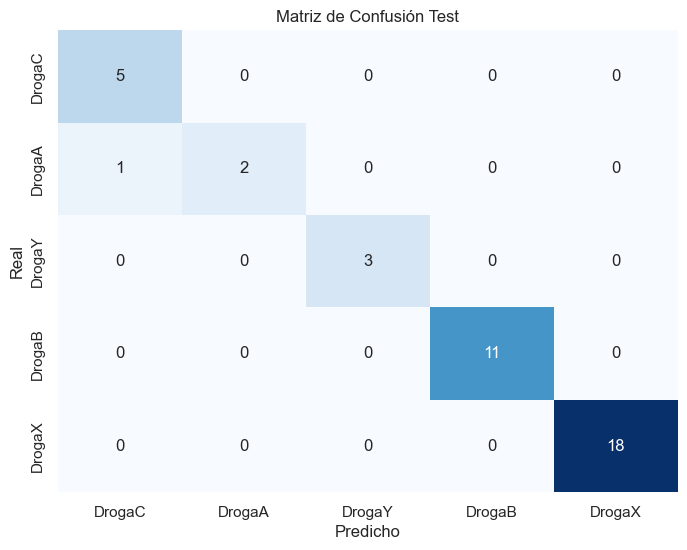

In [266]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_20_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas   
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

Solamente predice mal un valor, igual que en el split anterior.

# Bayes Ingenuo

In [267]:
df3 = df2.copy()

In [268]:
# Observación de estadísticas de variables numéricas
df3.describe()

,Edad,Na_a_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


Discretización de variables para Naive Bayes, basadas en lo visto anteriormente en describe, usando los cuartiles como referencia. 

In [269]:
df3['Na_a_K_Cat'] = pd.qcut(df3['Na_a_K'], q=4, labels=False)
df3['Edad_Cat'] = pd.qcut(df3['Edad'], q=4, labels = False)
df3 = df3.drop(columns=["Edad","Na_a_K"])

In [270]:
# Discretización de variables categóricas manteniendo la naturaleza ordinal de las mismas
df3['Sexo'] = df3['Sexo'].apply(lambda x: 1 if x == 'M' else 0)
bp_map = {'Bajo': 0, 'Normal': 1, 'Alto': 2}
df3['BP'] = df3['BP'].map(bp_map)
col_map = {'Normal': 0, 'Alto': 1}
df3['Colesterol'] = df3['Colesterol'].map(col_map)

In [271]:
X2 = df3.drop('Droga', axis=1)
y2 = df3['Droga']

# Primer split para naives
X_train80n, X_test20n, y_train80n, y_test20n = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2)

# Segundo split para naives
X_train70n, X_test30n, y_train70n, y_test30n = train_test_split(
    X2, y2, test_size=0.3, random_state=42, stratify=y2)

### 80-20 split

In [272]:
# Se utilizó MultinomialNB para variables discretas 
clf_MNB = MultinomialNB()
clf_MNB.fit(X_train80n, y_train80n)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [273]:
pred_MNB_train= clf_MNB.predict(X_train80n)
pred_MNB_test= clf_MNB.predict(X_test20n)

In [274]:
print("Resultados de Train:")
print(classification_report(y_train80n,pred_MNB_train,target_names = nombres_drogas,zero_division=0));

Resultados de Train:
              precision    recall  f1-score   support

      DrogaC       1.00      0.17      0.29        18
      DrogaA       0.00      0.00      0.00        13
      DrogaY       0.00      0.00      0.00        13
      DrogaB       0.48      0.53      0.51        43
      DrogaX       0.67      1.00      0.80        73

    accuracy                           0.62       160
   macro avg       0.43      0.34      0.32       160
weighted avg       0.55      0.62      0.53       160



In [275]:
print("Resultados de Test:")
print(classification_report(y_test20n,pred_MNB_test,target_names = nombres_drogas,zero_division=0));

Resultados de Test:
              precision    recall  f1-score   support

      DrogaC       0.00      0.00      0.00         5
      DrogaA       0.00      0.00      0.00         3
      DrogaY       0.00      0.00      0.00         3
      DrogaB       0.42      0.45      0.43        11
      DrogaX       0.61      0.94      0.74        18

    accuracy                           0.55        40
   macro avg       0.20      0.28      0.23        40
weighted avg       0.39      0.55      0.45        40



Se ven métricas con valores 0.0 tanto en train como en test, lo que puede indicar que debido a la naturaleza del split algunas combinaciones de atributos no se encuentran dentro de train, por lo que el modelo no tiene informacion suficiente para calcular la probabilidad condicional de ciertas clases, lo que hace que no pueda predecirlas. Este es un problema común con la implementación de Naive Bayes. 

### 70-30 split

In [276]:
# Se utilizó MultinomialNB para variables discretas 
clf_MNB2 = MultinomialNB()
clf_MNB2.fit(X_train70n, y_train70n)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [277]:
pred_MNB_train2 = clf_MNB2.predict(X_train70n)
pred_MNB_test2 = clf_MNB2.predict(X_test30n)

In [278]:
print("Resultados de Train:")
print(classification_report(y_train70n,pred_MNB_train2,target_names = nombres_drogas,zero_division=0));

Resultados de Train:
              precision    recall  f1-score   support

      DrogaC       1.00      0.12      0.22        16
      DrogaA       0.00      0.00      0.00        11
      DrogaY       0.00      0.00      0.00        11
      DrogaB       0.48      0.53      0.50        38
      DrogaX       0.67      1.00      0.80        64

    accuracy                           0.61       140
   macro avg       0.43      0.33      0.30       140
weighted avg       0.55      0.61      0.53       140



In [279]:
print("Resultados de Test:")
print(classification_report(y_test30n,pred_MNB_test2,target_names = nombres_drogas,zero_division=0));

Resultados de Test:
              precision    recall  f1-score   support

      DrogaC       1.00      0.14      0.25         7
      DrogaA       0.00      0.00      0.00         5
      DrogaY       0.00      0.00      0.00         5
      DrogaB       0.42      0.50      0.46        16
      DrogaX       0.65      0.96      0.78        27

    accuracy                           0.58        60
   macro avg       0.41      0.32      0.30        60
weighted avg       0.52      0.58      0.50        60



Nuevamente se observa el mismo comportamiento que en el split de 80-20.

# KNN

In [280]:
# Se realizan nuevamente los splits para evitar conflictos con modificaciones previas
X3 = df2_copy.drop('Droga', axis=1)
y3 = df2_copy['Droga']

# Primer split knn
X_train80k, X_test20k, y_train80k, y_test20k = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3)
# Segundo split knn
X_train70k, X_test30k, y_train70k, y_test30k = train_test_split(
    X3, y3, test_size=0.3, random_state=42, stratify=y3)

In [281]:
scaler = StandardScaler()

# Escalado primer split
X_train80k_scaled = scaler.fit_transform(X_train80k)
X_test20k_scaled = scaler.transform(X_test20k)

# Escalado segundo split
X_train70k_scaled = scaler.fit_transform(X_train70k)
X_test30k_scaled = scaler.transform(X_test30k)

In [282]:
knn = KNeighborsClassifier()

Se prueban como parámetros un rango relativamente amplio de vecinos y la distancia de Manhattan y la euclidiana.

In [283]:
# Definir los parámetros a ajustar
parametros_grid = {'n_neighbors': range(3, 30),
                   'p':[1,2],
                   }

### 80-20 split

In [284]:
# Inicializar el objeto GridSearchCV
grid_search = GridSearchCV(estimator = knn,
                           param_grid = parametros_grid,
                           cv=5,
                           scoring='f1_weighted') # se selecciona f1_weighted ya que considera metricas de recall como de precision.

In [285]:
grid_search.fit(X_train80k_scaled, y_train80k)
print(f"Mejores parámetros encontrados: {grid_search.best_params_}")

Mejores parámetros encontrados: {'n_neighbors': 5, 'p': 1}


In [286]:
best_knn80 = grid_search.best_estimator_

In [287]:
y_pred_train80k = best_knn80.predict(X_train80k_scaled)
y_pred_test20k = best_knn80.predict(X_test20k_scaled)

In [288]:
confusion_k_train80 = confusion_matrix(y_train80k,y_pred_train80k)
confusion_k_test80 = confusion_matrix(y_test20k,y_pred_test20k)

In [289]:
print("Resultados de Train:")
print(classification_report(
    y_train80k, 
    y_pred_train80k, 
    target_names=nombres_drogas
))

Resultados de Train:
              precision    recall  f1-score   support

      DrogaC       0.88      0.83      0.86        18
      DrogaA       0.86      0.92      0.89        13
      DrogaY       0.87      1.00      0.93        13
      DrogaB       0.88      1.00      0.93        43
      DrogaX       0.97      0.86      0.91        73

    accuracy                           0.91       160
   macro avg       0.89      0.92      0.90       160
weighted avg       0.92      0.91      0.91       160



Las métricas en train son positivas con todas las clases, no se presenta algún sesgo particular por el desbalance de las clases.

In [290]:
print("Resultados de Test:")
print(classification_report(
    y_test20k, 
    y_pred_test20k, 
    target_names=nombres_drogas
))

Resultados de Test:
              precision    recall  f1-score   support

      DrogaC       0.50      0.80      0.62         5
      DrogaA       0.50      0.67      0.57         3
      DrogaY       1.00      1.00      1.00         3
      DrogaB       0.91      0.91      0.91        11
      DrogaX       0.93      0.72      0.81        18

    accuracy                           0.80        40
   macro avg       0.77      0.82      0.78        40
weighted avg       0.84      0.80      0.81        40



Las métricas de train muestran valores de f-1 score mas bajos para dos de las categorías que cuentan con un menor número de entradas (C y A). Las métricas para la categoría mayoritaria(Droga Y) son perfectas. Para las demás no minoritarias también se ve un buen resultado. 

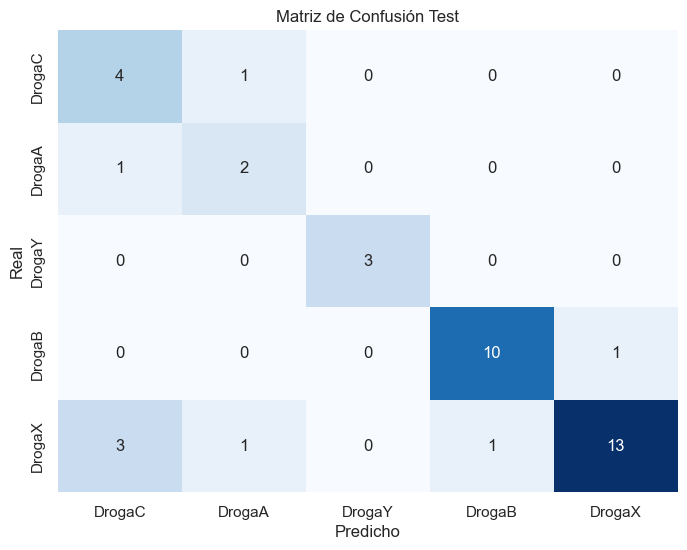

In [291]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_test80,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

### 70-30 split

In [292]:
# Inicializar el objeto GridSearchCV
grid_search2 = GridSearchCV(estimator = knn,
                           param_grid = parametros_grid,
                           cv=5,
                           scoring='f1_weighted') # se selecciona f1_weighted ya que considera metricas de recall como de precision.

In [293]:
grid_search2.fit(X_train70k_scaled, y_train70k)
print(f"Mejores parámetros encontrados: {grid_search2.best_params_}")

Mejores parámetros encontrados: {'n_neighbors': 3, 'p': 1}


In [294]:
best_knn70 = grid_search2.best_estimator_

In [295]:
y_pred_train70k = best_knn70.predict(X_train70k_scaled)
y_pred_test30k = best_knn70.predict(X_test30k_scaled)

In [296]:
confusion_k_train70 = confusion_matrix(y_train70k,y_pred_train70k)
confusion_k_test70 = confusion_matrix(y_test30k,y_pred_test30k)

In [297]:
print("Resultados de Train:")
print(classification_report(
    y_train70k, 
    y_pred_train70k, 
    target_names=nombres_drogas
))

Resultados de Train:
              precision    recall  f1-score   support

      DrogaC       0.94      1.00      0.97        16
      DrogaA       0.92      1.00      0.96        11
      DrogaY       0.85      1.00      0.92        11
      DrogaB       0.93      1.00      0.96        38
      DrogaX       1.00      0.89      0.94        64

    accuracy                           0.95       140
   macro avg       0.93      0.98      0.95       140
weighted avg       0.95      0.95      0.95       140



In [298]:
print("Resultados de Test:")
print(classification_report(
    y_test30k, 
    y_pred_test30k, 
    target_names=nombres_drogas
))

Resultados de Test:
              precision    recall  f1-score   support

      DrogaC       0.57      0.57      0.57         7
      DrogaA       0.57      0.80      0.67         5
      DrogaY       0.62      1.00      0.77         5
      DrogaB       0.88      0.94      0.91        16
      DrogaX       0.95      0.74      0.83        27

    accuracy                           0.80        60
   macro avg       0.72      0.81      0.75        60
weighted avg       0.83      0.80      0.80        60



Los resultados obtenidos con este split son muy similares a los obtenidos anteriormente. Los resultados en train son casi perfectos y luego en test las métricas de categorías con menor cantidad de entradas empeoran, lo que es de esperarse. 

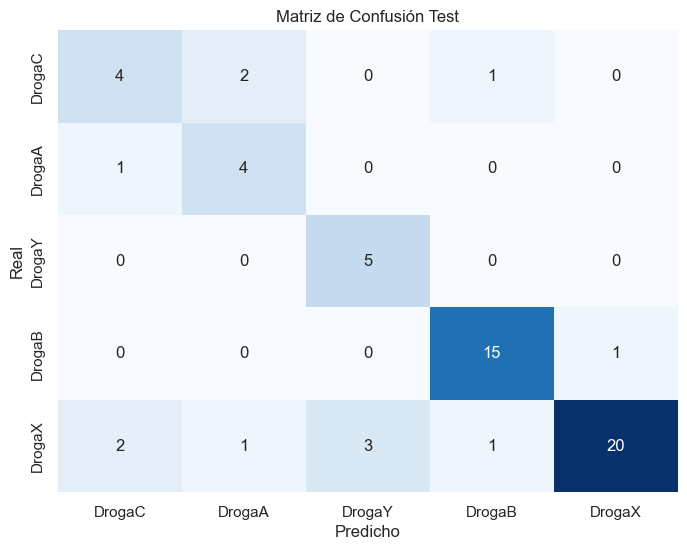

In [299]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    confusion_k_test70,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=nombres_drogas,  
    yticklabels=nombres_drogas 
)

plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión Test')
plt.show()

# Conclusión 

**Árboles**: Los resultados obtenidos fueron positivos para el caso de la *regresión* con el dataset de companies, obteniendo valores de R2 superiores a 0.85 para cada split realizado. Se intuye que esto es así debido a la alta correlación lineal entre las variables numéricas dentro del dataset. 

En cuanto a la *clasificación*, los resultados también fueron sumamente positivos con el dataset de drogas, obteniendo predicciones sólidas para casi todas las clases. Este algoritmo fue el que dió mejores resultados con este dataset en comparación a los que se mencionarán a continuación. 

**Bayes Ingenuo**: Los resultados para el dataset de drogas fueron negativos. Las métricas de algunas variables minoritarias e incluso algunas que no lo eran terminan siendo 0. Como se mencionó anteriormente, este problema es común con Naive Bayes y depende de que se formen las combinaciones entre las diferentes variables en el conjunto de train, de manera que el modelo tenga la capacidad de generalizar en test y en producción.

**KNN**: Los resultados son nuevamente positivos a la hora de clasificar con este algoritmo, aunque se nota un impacto más directo del desbalance de clases en el resultado final en comparación a la clasificación con árboles.

Los Árboles de Decisión demostraron ser el algoritmo más robusto y versátil de la comparativa. No solo dominaron en la tarea de regresión (R2 > 0.85), sino que también ofrecieron los mejores resultados en clasificación, manejando eficazmente el desbalance de clases. Aunque KNN fue competente en clasificación, sus métricas se vieron más afectadas por dicho desbalance. Por su parte, Naive Bayes resultó inviable para el dataset de drogas; el conocido problema de "frecuencia cero" anuló las predicciones de varias clases. En definitiva, el Árbol de Decisión se consolidó como la solución superior para el trabajo realizado, adaptándose con éxito a ambos escenarios.

